In [18]:
import os
import urllib.request
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [19]:
url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
urllib.request.urlretrieve(url, "hymenoptera_data.zip")
with zipfile.ZipFile("hymenoptera_data.zip", 'r') as zip_ref:
    zip_ref.extractall(".")
    os.remove("hymenoptera_data.zip")

data_dir = 'hymenoptera_data'

In [20]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'))
class_names = train_dataset.classes
class_counts = {cls: sum(1 for _, label in train_dataset.imgs if label == i)
                for i, cls in enumerate(class_names)}

print(f"Классы: {class_names}")
print(f"Распределение в train: {class_counts}")
print(f"Дисбаланс: {'Отсутствует' if max(class_counts.values())/min(class_counts.values()) < 1.5 else 'Есть дисбаланс'}\n")

Классы: ['ants', 'bees']
Распределение в train: {'ants': 123, 'bees': 121}
Дисбаланс: Отсутствует



In [21]:
IMG_SIZE = 224
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=16, shuffle=(x=='train'), num_workers=2) for x in ['train', 'val']}

In [22]:
def get_model(name, num_classes):
    if name == 'resnet':
        return models.resnet18(weights=None, num_classes=num_classes)

    elif name == 'vgg':
        return models.vgg16(weights=None, num_classes=num_classes)

    elif name == 'inception':
        return models.inception_v3(weights=None, num_classes=num_classes, aux_logits=False)

    elif name == 'densenet':
        return models.densenet161(weights=None, num_classes=num_classes)

In [23]:
def train_one_model(model, train_loader, val_loader, num_epochs=3, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        # train
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        train_losses.append(running_loss / len(train_loader.dataset))

        # valid
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
        val_losses.append(val_loss / len(val_loader.dataset))

        print(f"Epoch {epoch+1}\n")
        print(f"Train: {train_losses[-1]}\n")
        print(f"Val: {val_losses[-1]}")

    return train_losses, val_losses

In [24]:
NUM_EPOCHS = 3
models_list = ['resnet', 'vgg', 'inception', 'densenet']
results = {}

for m_name in models_list:
    print(m_name)
    torch.cuda.empty_cache()
    model = get_model(m_name, num_classes=len(class_names))
    train_loss, val_loss = train_one_model(model, dataloaders['train'], dataloaders['val'], num_epochs=NUM_EPOCHS)
    results[m_name] = {'train': train_loss, 'val': val_loss}

resnet


Epoch 1

Train: 1.0512805908429819

Val: 78.17943272030747


Epoch 2

Train: 0.6981440772775744

Val: 1.2718810532607285


Epoch 3

Train: 0.645152777921958

Val: 0.8451652935906953
vgg


Epoch 1

Train: 30.954433312181568

Val: 0.6945140774733101


...

Epoch 2

Train: 1.7476306352459017

Val: 8.881422357621537


Epoch 3

Train: 1.8660537356235942

Val: 4.682005207523022
densenet


Epoch 1

Train: 0.8779894680273338

Val: 21.295666984483308


Epoch 2

Train: 0.6630985873644469

Val: 1.1714002821180556


Epoch 3

Train: 0.6847279794880601

Val: 0.8453579895636615


Результаты обучения сетей:

| Model     |   Epoch_1_Train_Loss |   Epoch_1_Val_Loss |   Epoch_2_Train_Loss |   Epoch_2_Val_Loss |   Epoch_3_Train_Loss |   Epoch_3_Val_Loss |   Final_Val_Loss |    Loss_Drop |
|:----------|---------------------:|-------------------:|---------------------:|-------------------:|---------------------:|-------------------:|-----------------:|-------------:|
| resnet    |             1.05128  |          78.1794   |             0.698144 |           1.27188  |             0.645153 |           0.845165 |         0.845165 |  77.3343     |
| vgg       |            30.9544   |           0.694514 |             0.693367 |           0.696502 |             0.693863 |           0.697346 |         0.697346 |  -0.00283158 |
| inception |             2.64145  |         105.903    |             1.74763  |           8.88142  |             1.86605  |           4.68201  |         4.68201  | 101.221      |
| densenet  |             0.877989 |          21.2957   |             0.

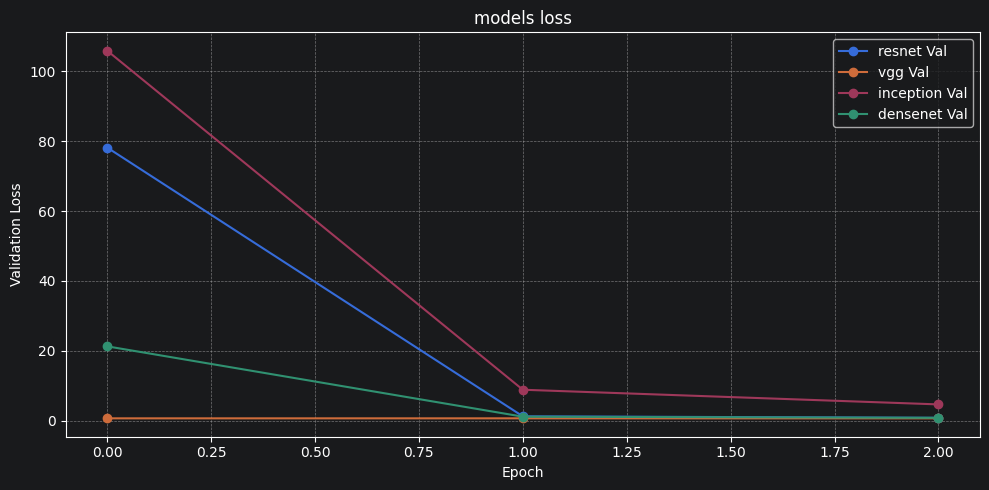

In [26]:
df_rows = []
for m in models_list:
    row = {'Model': m}
    for i, (tl, vl) in enumerate(zip(results[m]['train'], results[m]['val']), 1):
        row[f'Epoch_{i}_Train_Loss'] = tl
        row[f'Epoch_{i}_Val_Loss'] = vl
    row['Final_Val_Loss'] = results[m]['val'][-1]
    row['Loss_Drop'] = results[m]['val'][0] - results[m]['val'][-1]
    df_rows.append(row)

df_results = pd.DataFrame(df_rows)
print("Результаты обучения сетей:\n")
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(df_results.to_markdown(index=False))

# График loss
plt.figure(figsize=(10, 5))
for m in models_list:
    plt.plot(results[m]['val'], marker='o', label=f'{m} Val')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('models loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()